In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, classification_report

In [2]:
df = pd.read_excel('cancer patient data sets.xlsx')
df.head()

,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,P1,33,1,2,4,5,4,3,2,2,...,3,4,2,2,3,1,2,3,4,Low
1,P10,17,1,3,1,5,3,4,2,2,...,1,3,7,8,6,2,1,7,2,Medium
2,P100,35,1,4,5,6,5,5,4,6,...,8,7,9,2,1,4,6,7,2,High
3,P1000,37,1,7,7,7,7,6,7,7,...,4,2,3,1,4,5,6,7,5,High
4,P101,46,1,6,8,7,7,7,6,7,...,3,2,4,1,4,2,4,2,3,High


In [3]:
df = df.drop('Patient Id', axis=1)
df.head()

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,33,1,2,4,5,4,3,2,2,4,...,3,4,2,2,3,1,2,3,4,Low
1,17,1,3,1,5,3,4,2,2,2,...,1,3,7,8,6,2,1,7,2,Medium
2,35,1,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,High
3,37,1,7,7,7,7,6,7,7,7,...,4,2,3,1,4,5,6,7,5,High
4,46,1,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,High


In [4]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,37.17,12.01,14.0,27.75,36.0,45.0,73.0
Gender,1000.0,1.40,0.49,1.0,1.00,1.0,2.0,2.0
Air Pollution,1000.0,3.84,2.03,1.0,2.00,3.0,6.0,8.0
Alcohol use,1000.0,4.56,2.62,1.0,2.00,5.0,7.0,8.0
Dust Allergy,1000.0,5.16,1.98,1.0,4.00,6.0,7.0,8.0
OccuPational Hazards,1000.0,4.84,2.11,1.0,3.00,5.0,7.0,8.0
Genetic Risk,1000.0,4.58,2.13,1.0,2.00,5.0,7.0,7.0
chronic Lung Disease,1000.0,4.38,1.85,1.0,3.00,4.0,6.0,7.0
Balanced Diet,1000.0,4.49,2.14,1.0,2.00,4.0,7.0,7.0
Obesity,1000.0,4.46,2.12,1.0,3.00,4.0,7.0,7.0


In [5]:
# Tabla equivalente a df.info()
info_table = pd.DataFrame(
    {
        "Non-Null Count": df.notna().sum(),
        "Null Count": df.isna().sum(),
        "Dtype": df.dtypes.astype(str),
    }
)
info_table.index.name = "Column"
display(info_table.reset_index())

,Column,Non-Null Count,Null Count,Dtype
0,Age,1000,0,int64
1,Gender,1000,0,int64
2,Air Pollution,1000,0,int64
3,Alcohol use,1000,0,int64
4,Dust Allergy,1000,0,int64
5,OccuPational Hazards,1000,0,int64
6,Genetic Risk,1000,0,int64
7,chronic Lung Disease,1000,0,int64
8,Balanced Diet,1000,0,int64
9,Obesity,1000,0,int64


Filas, columnas: (1000, 24)


Column,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,33,1,2,4,5,4,3,2,2,4,...,3,4,2,2,3,1,2,3,4,Low
1,17,1,3,1,5,3,4,2,2,2,...,1,3,7,8,6,2,1,7,2,Medium
2,35,1,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,High
3,37,1,7,7,7,7,6,7,7,7,...,4,2,3,1,4,5,6,7,5,High
4,46,1,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,High


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1000 non-null   int64 
 1   Gender                    1000 non-null   int64 
 2   Air Pollution             1000 non-null   int64 
 3   Alcohol use               1000 non-null   int64 
 4   Dust Allergy              1000 non-null   int64 
 5   OccuPational Hazards      1000 non-null   int64 
 6   Genetic Risk              1000 non-null   int64 
 7   chronic Lung Disease      1000 non-null   int64 
 8   Balanced Diet             1000 non-null   int64 
 9   Obesity                   1000 non-null   int64 
 10  Smoking                   1000 non-null   int64 
 11  Passive Smoker            1000 non-null   int64 
 12  Chest Pain                1000 non-null   int64 
 13  Coughing of Blood         1000 non-null   int64 
 14  Fatigue                  

,count
Level,
High,365
Medium,332
Low,303


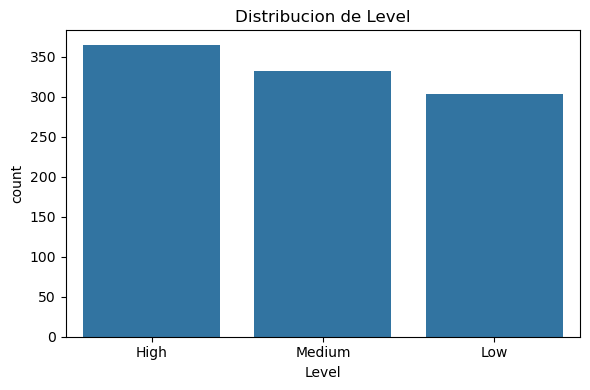

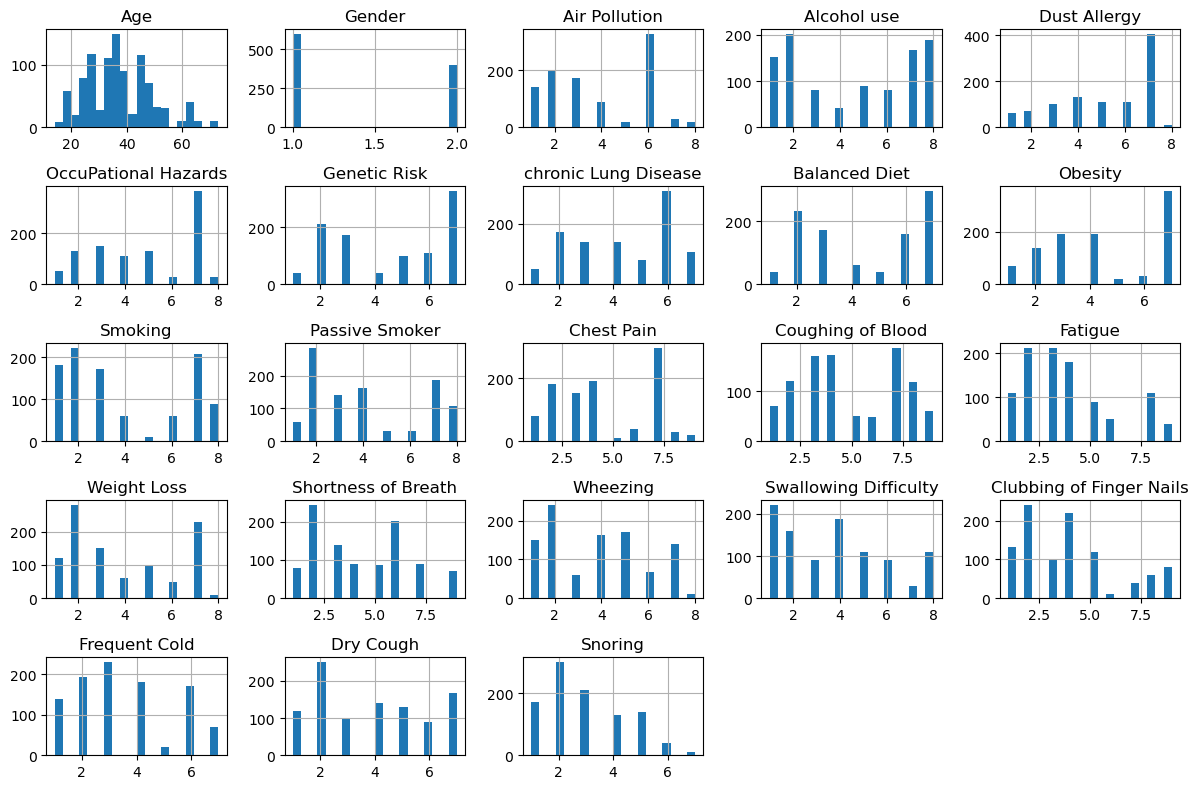

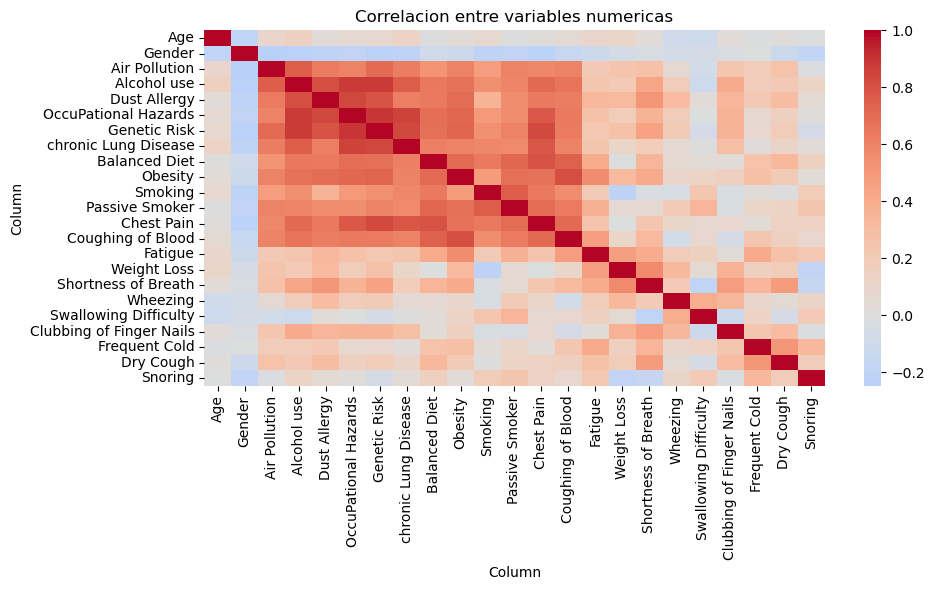

In [26]:
# EDA basico

print("Filas, columnas:", df.shape)

display(df.head())

df.info()

missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Duplicated rows:", df.duplicated().sum())
missing

# Estadisticas descriptivas

df.describe(include="all").T

cat_cols = df.select_dtypes(exclude="number").columns
if len(cat_cols) > 0:
    for col in cat_cols:
        display(df[col].value_counts().rename_axis(col).to_frame("count"))
else:
    print("No categorical columns to summarize.")

plt.figure(figsize=(6, 4))
sns.countplot(x="Level", data=df, order=df["Level"].value_counts().index)
plt.title("Distribucion de Level")
plt.tight_layout()
plt.show()

num_cols = df.select_dtypes(include="number").columns
if len(num_cols) > 0:
    df[num_cols].hist(figsize=(12, 8), bins=20)
    plt.tight_layout()
    plt.show()

    corr = df[num_cols].corr()
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Correlacion entre variables numericas")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns to plot.")

<Axes: xlabel='Level', ylabel='Age'>

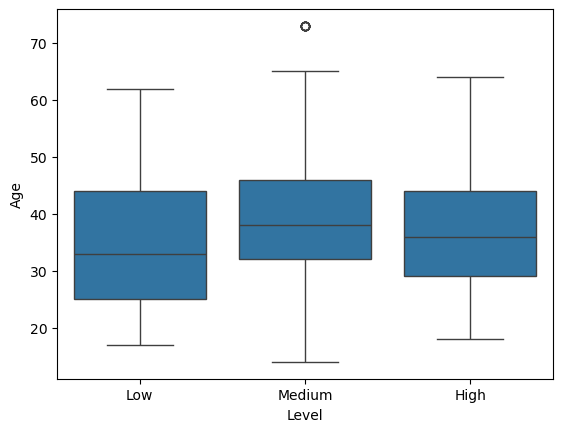

In [7]:
sns.boxplot(x="Level", y="Age", data=df)

In [6]:
df.groupby("Level").mean()

Column,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Coughing of Blood,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring
Level,,,,,,,,,,,,,,,,,,,,,
High,37.320548,1.309589,5.693151,6.830137,6.616438,6.479452,6.375342,5.827397,6.619178,6.682192,...,7.438356,5.589041,4.468493,5.328767,3.884932,4.189041,4.208219,4.380822,4.775342,3.227397
Low,35.412541,1.508251,2.600660,2.231023,3.112211,3.000000,2.732673,3.092409,3.000000,2.409241,...,2.861386,2.171617,2.501650,2.498350,2.574257,2.759076,2.468647,2.366337,2.914191,2.141914
Medium,38.620482,1.406627,2.933735,4.198795,5.442771,4.716867,4.292169,3.963855,3.512048,3.903614,...,3.846386,3.487952,4.415663,4.632530,4.756024,4.159639,4.936747,3.674699,3.695783,3.310241


Level,High,Low,Medium
Smoking,,,
1,0.000000,0.201320,0.361446
2,0.191781,0.267327,0.213855
3,0.000000,0.234323,0.304217
4,0.052055,0.132013,0.000000
5,0.000000,0.000000,0.030120
6,0.027397,0.099010,0.060241
7,0.512329,0.066007,0.000000
8,0.216438,0.000000,0.030120


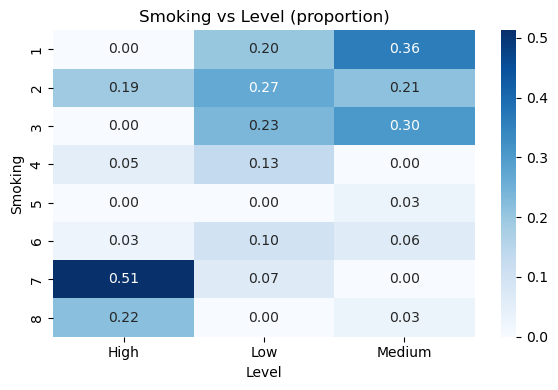

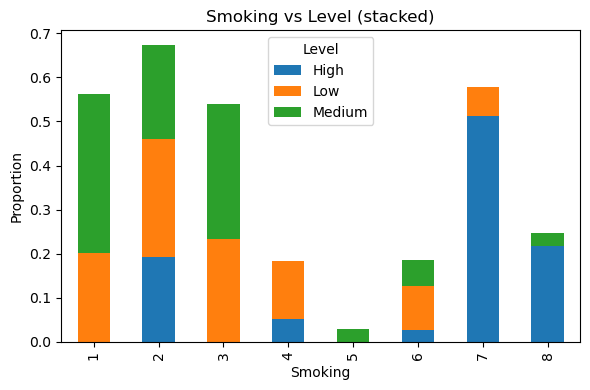

In [9]:
ct = pd.crosstab(df["Smoking"], df["Level"], normalize="columns")
display(ct)

plt.figure(figsize=(6, 4))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues")
plt.title("Smoking vs Level (proportion)")
plt.tight_layout()
plt.show()

ax = ct.plot(kind="bar", stacked=True, figsize=(6, 4))
ax.set_title("Smoking vs Level (stacked)")
ax.set_xlabel("Smoking")
ax.set_ylabel("Proportion")
plt.tight_layout()
plt.show()

Categorical/discrete columns (22): ['Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring']

Variable: Gender


C:\Users\jjvil\AppData\Local\Temp\ipykernel_36936\929233694.py:25: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_bool_dtype(series) or pd.api.types.is_object_dtype(series) or pd.api.types.is_categorical_dtype(series):


Level,High,Low,Medium
Gender,,,
1,0.690411,0.491749,0.593373
2,0.309589,0.508251,0.406627


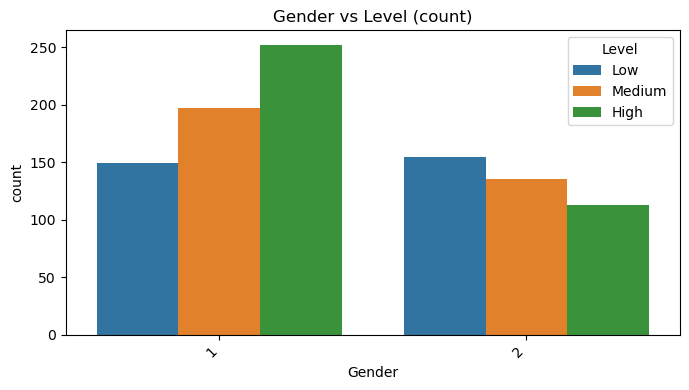

Conclusion: dominante por nivel -> High: 1, Low: 2, Medium: 1. Mayor brecha: High (gap 0.38).

Variable: Air Pollution


Level,High,Low,Medium
Air Pollution,,,
1,0.000000,0.132013,0.304217
2,0.054795,0.366337,0.210843
3,0.000000,0.369637,0.183735
4,0.136986,0.066007,0.060241
5,0.000000,0.033003,0.030120
6,0.673973,0.033003,0.210843
7,0.082192,0.000000,0.000000
8,0.052055,0.000000,0.000000


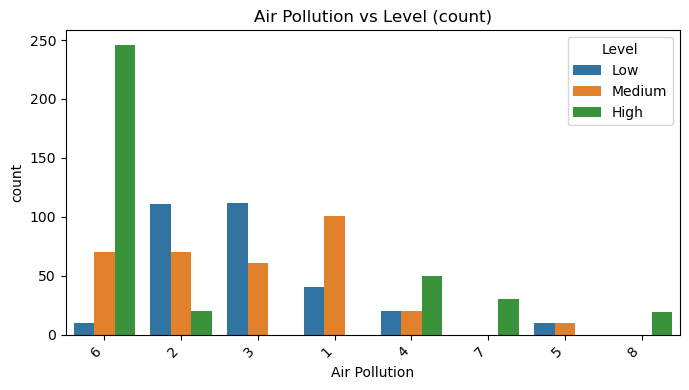

Conclusion: dominante por nivel -> High: 6, Low: 3, Medium: 1. Mayor brecha: High (gap 0.67).

Variable: Alcohol use


Level,High,Low,Medium
Alcohol use,,,
1,0.000000,0.303630,0.180723
2,0.000000,0.363036,0.277108
3,0.000000,0.231023,0.030120
4,0.027397,0.069307,0.030120
5,0.191781,0.000000,0.060241
6,0.027397,0.000000,0.210843
7,0.430137,0.033003,0.000000
8,0.323288,0.000000,0.210843


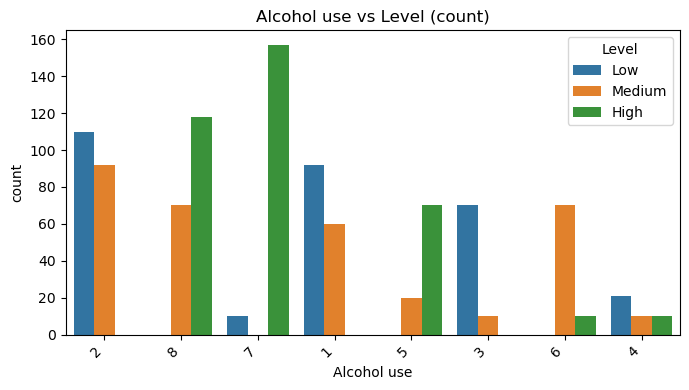

Conclusion: dominante por nivel -> High: 7, Low: 2, Medium: 2. Mayor brecha: High (gap 0.43).

Variable: Dust Allergy


Level,High,Low,Medium
Dust Allergy,,,
1,0.000000,0.198020,0.000000
2,0.027397,0.198020,0.000000
3,0.000000,0.198020,0.123494
4,0.000000,0.237624,0.183735
5,0.027397,0.102310,0.210843
6,0.191781,0.033003,0.090361
7,0.753425,0.000000,0.391566
8,0.000000,0.033003,0.000000


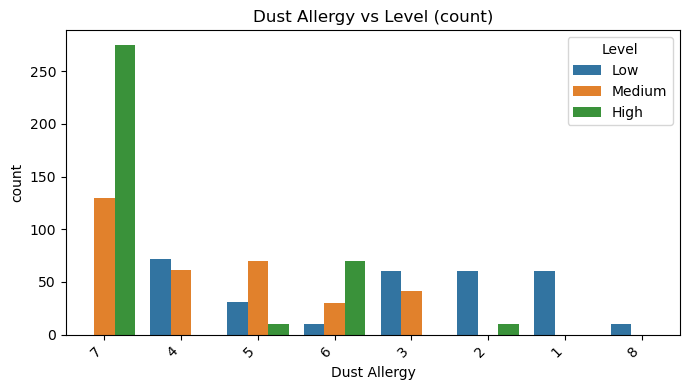

Conclusion: dominante por nivel -> High: 7, Low: 4, Medium: 7. Mayor brecha: High (gap 0.75).

Variable: OccuPational Hazards


Level,High,Low,Medium
OccuPational Hazards,,,
1,0.000000,0.165017,0.000000
2,0.000000,0.234323,0.183735
3,0.027397,0.267327,0.180723
4,0.000000,0.234323,0.123494
5,0.191781,0.033003,0.150602
6,0.027397,0.000000,0.060241
7,0.753425,0.066007,0.210843
8,0.000000,0.000000,0.090361


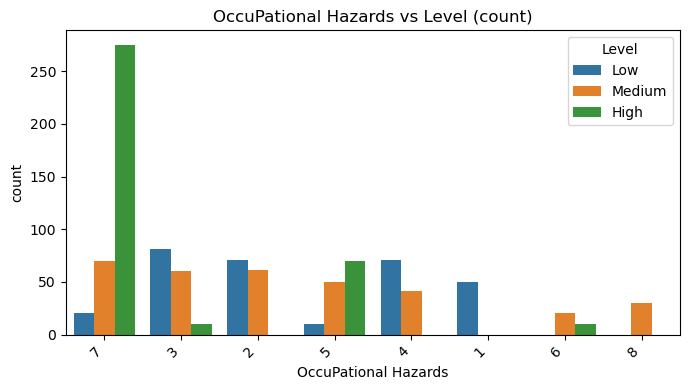

Conclusion: dominante por nivel -> High: 7, Low: 3, Medium: 7. Mayor brecha: High (gap 0.75).

Variable: Genetic Risk


Level,High,Low,Medium
Genetic Risk,,,
1,0.000000,0.132013,0.000000
2,0.000000,0.399340,0.274096
3,0.000000,0.303630,0.243976
4,0.000000,0.066007,0.060241
5,0.219178,0.000000,0.060241
6,0.186301,0.066007,0.060241
7,0.594521,0.033003,0.301205


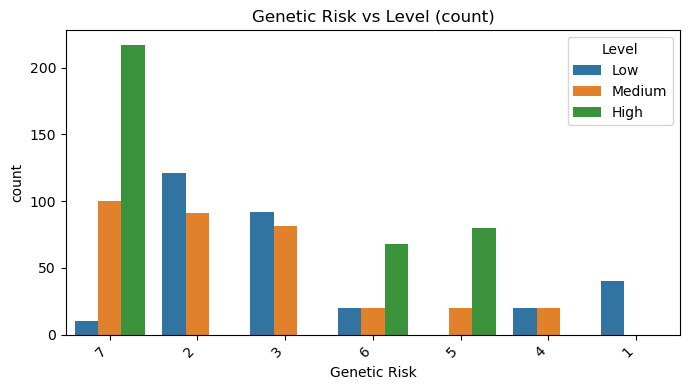

Conclusion: dominante por nivel -> High: 7, Low: 2, Medium: 7. Mayor brecha: High (gap 0.59).

Variable: chronic Lung Disease


Level,High,Low,Medium
chronic Lung Disease,,,
1,0.000000,0.165017,0.000000
2,0.000000,0.270627,0.274096
3,0.000000,0.267327,0.180723
4,0.191781,0.066007,0.153614
5,0.027397,0.132013,0.090361
6,0.542466,0.033003,0.301205
7,0.238356,0.066007,0.000000


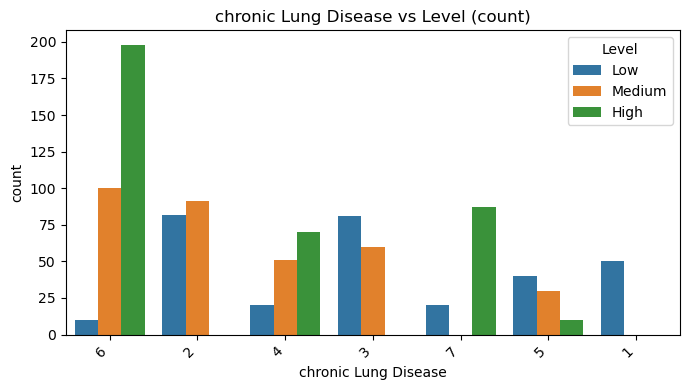

Conclusion: dominante por nivel -> High: 6, Low: 2, Medium: 6. Mayor brecha: High (gap 0.54).

Variable: Balanced Diet


Level,High,Low,Medium
Balanced Diet,,,
1,0.000000,0.132013,0.000000
2,0.000000,0.333333,0.391566
3,0.000000,0.234323,0.307229
4,0.027397,0.135314,0.030120
5,0.000000,0.099010,0.030120
6,0.298630,0.000000,0.150602
7,0.673973,0.066007,0.090361


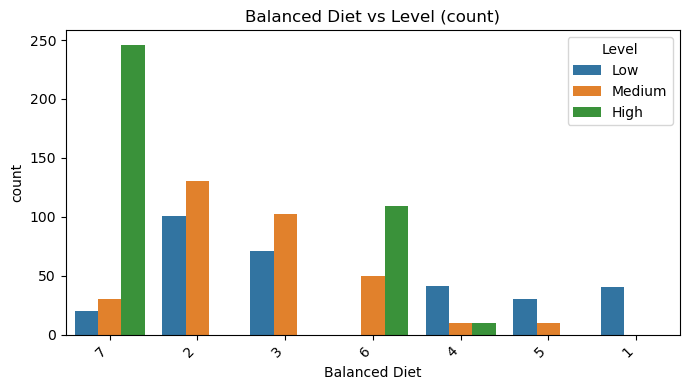

Conclusion: dominante por nivel -> High: 7, Low: 2, Medium: 2. Mayor brecha: High (gap 0.67).

Variable: Obesity


Level,High,Low,Medium
Obesity,,,
1,0.000000,0.231023,0.000000
2,0.000000,0.330033,0.120482
3,0.052055,0.237624,0.307229
4,0.027397,0.201320,0.361446
5,0.000000,0.000000,0.060241
6,0.027397,0.000000,0.060241
7,0.893151,0.000000,0.090361


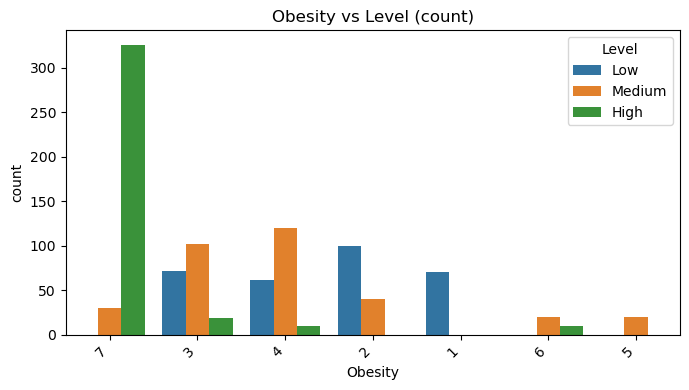

Conclusion: dominante por nivel -> High: 7, Low: 2, Medium: 4. Mayor brecha: High (gap 0.89).

Variable: Smoking


Level,High,Low,Medium
Smoking,,,
1,0.000000,0.201320,0.361446
2,0.191781,0.267327,0.213855
3,0.000000,0.234323,0.304217
4,0.052055,0.132013,0.000000
5,0.000000,0.000000,0.030120
6,0.027397,0.099010,0.060241
7,0.512329,0.066007,0.000000
8,0.216438,0.000000,0.030120


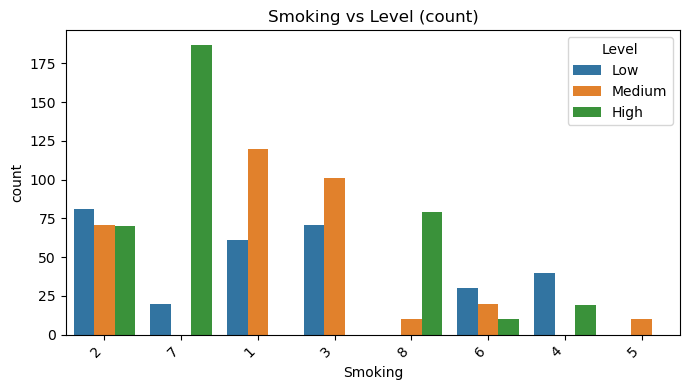

Conclusion: dominante por nivel -> High: 7, Low: 2, Medium: 1. Mayor brecha: High (gap 0.51).

Variable: Passive Smoker


Level,High,Low,Medium
Passive Smoker,,,
1,0.000000,0.198020,0.000000
2,0.000000,0.402640,0.487952
3,0.191781,0.099010,0.120482
4,0.000000,0.201320,0.301205
5,0.000000,0.066007,0.030120
6,0.000000,0.033003,0.060241
7,0.512329,0.000000,0.000000
8,0.295890,0.000000,0.000000


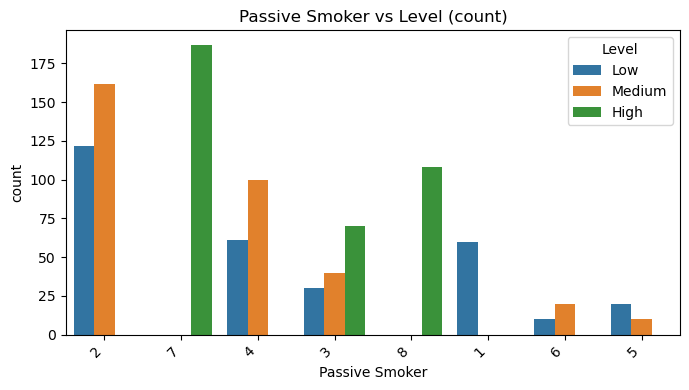

Conclusion: dominante por nivel -> High: 7, Low: 2, Medium: 2. Mayor brecha: High (gap 0.51).

Variable: Chest Pain


Level,High,Low,Medium
Chest Pain,,,
1,0.000000,0.264026,0.000000
2,0.027397,0.267327,0.271084
3,0.000000,0.201320,0.277108
4,0.191781,0.135314,0.240964
5,0.000000,0.000000,0.030120
6,0.000000,0.033003,0.090361
7,0.728767,0.099010,0.000000
8,0.000000,0.000000,0.090361
9,0.052055,0.000000,0.000000


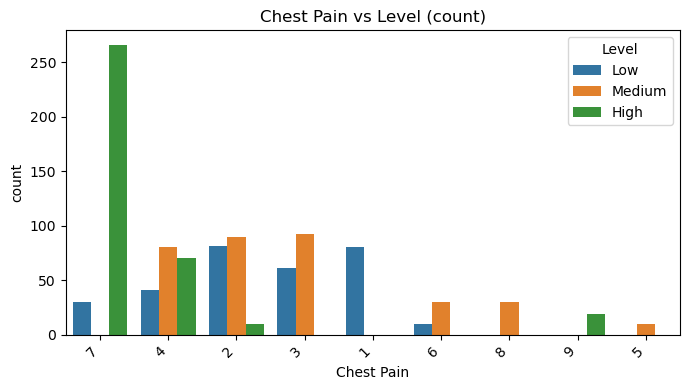

Conclusion: dominante por nivel -> High: 7, Low: 2, Medium: 3. Mayor brecha: High (gap 0.73).

Variable: Coughing of Blood


Level,High,Low,Medium
Coughing of Blood,,,
1,0.000000,0.234323,0.000000
2,0.000000,0.300330,0.090361
3,0.027397,0.099010,0.394578
4,0.000000,0.234323,0.304217
5,0.000000,0.066007,0.090361
6,0.079452,0.033003,0.030120
7,0.430137,0.000000,0.090361
8,0.298630,0.033003,0.000000
9,0.164384,0.000000,0.000000


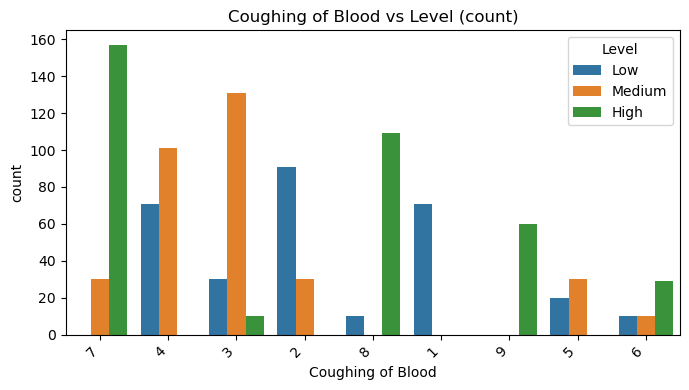

Conclusion: dominante por nivel -> High: 7, Low: 2, Medium: 3. Mayor brecha: High (gap 0.43).

Variable: Fatigue


Level,High,Low,Medium
Fatigue,,,
1,0.000000,0.264026,0.090361
2,0.082192,0.366337,0.210843
3,0.164384,0.303630,0.180723
4,0.158904,0.066007,0.307229
5,0.189041,0.000000,0.060241
6,0.000000,0.000000,0.150602
8,0.298630,0.000000,0.000000
9,0.106849,0.000000,0.000000


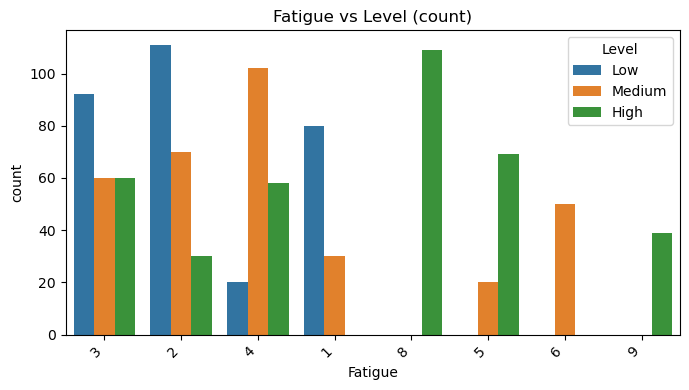

Conclusion: dominante por nivel -> High: 8, Low: 2, Medium: 4. Mayor brecha: Low (gap 0.37).

Variable: Weight Loss


Level,High,Low,Medium
Weight Loss,,,
1,0.000000,0.264026,0.123494
2,0.323288,0.402640,0.120482
3,0.109589,0.132013,0.210843
4,0.052055,0.102310,0.030120
5,0.106849,0.033003,0.153614
6,0.106849,0.033003,0.000000
7,0.301370,0.000000,0.361446
8,0.000000,0.033003,0.000000


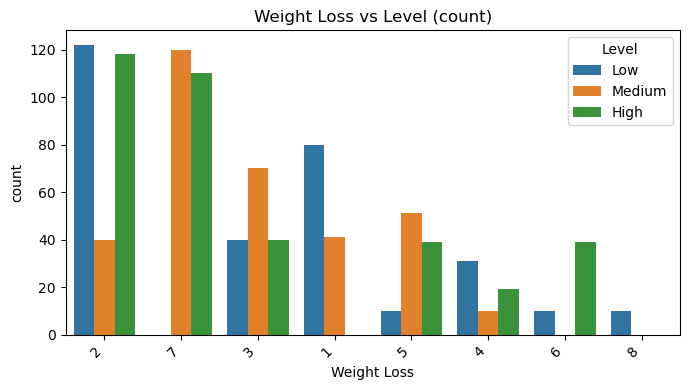

Conclusion: dominante por nivel -> High: 2, Low: 2, Medium: 7. Mayor brecha: Low (gap 0.40).

Variable: Shortness of Breath


Level,High,Low,Medium
Shortness of Breath,,,
1,0.000000,0.264026,0.000000
2,0.109589,0.303630,0.334337
3,0.106849,0.300330,0.030120
4,0.191781,0.033003,0.030120
5,0.210959,0.033003,0.000000
6,0.082192,0.033003,0.484940
7,0.106849,0.033003,0.120482
9,0.191781,0.000000,0.000000


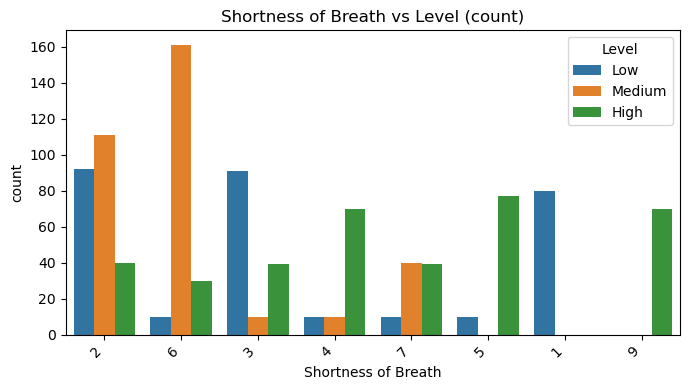

Conclusion: dominante por nivel -> High: 5, Low: 2, Medium: 6. Mayor brecha: Medium (gap 0.48).

Variable: Wheezing


Level,High,Low,Medium
Wheezing,,,
1,0.271233,0.132013,0.030120
2,0.243836,0.432343,0.060241
3,0.027397,0.165017,0.000000
4,0.000000,0.270627,0.243976
5,0.000000,0.000000,0.515060
6,0.158904,0.000000,0.030120
7,0.298630,0.000000,0.090361
8,0.000000,0.000000,0.030120


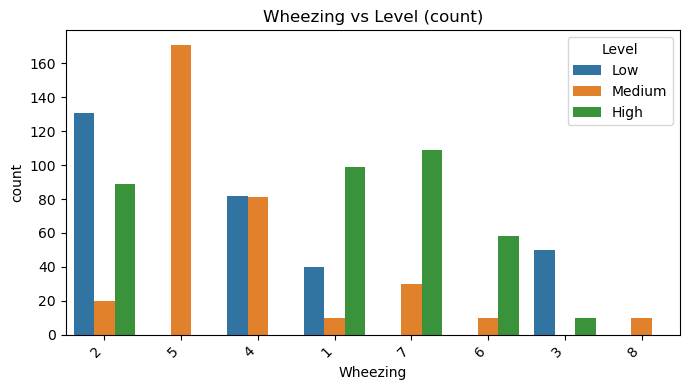

Conclusion: dominante por nivel -> High: 7, Low: 2, Medium: 5. Mayor brecha: Medium (gap 0.52).

Variable: Swallowing Difficulty


Level,High,Low,Medium
Swallowing Difficulty,,,
1,0.191781,0.234323,0.240964
2,0.106849,0.300330,0.090361
3,0.052055,0.201320,0.030120
4,0.271233,0.132013,0.150602
5,0.079452,0.066007,0.183735
6,0.082192,0.033003,0.153614
7,0.079452,0.000000,0.000000
8,0.136986,0.033003,0.150602


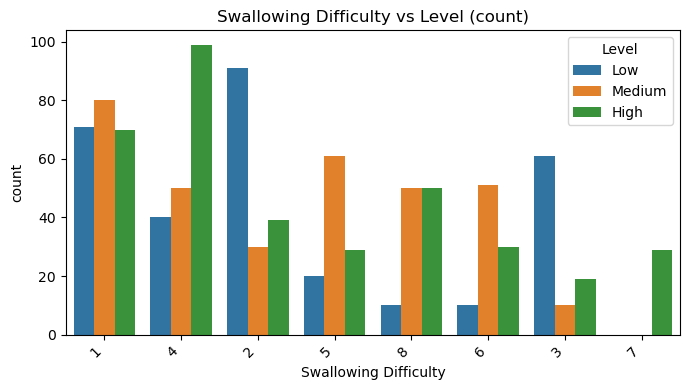

Conclusion: dominante por nivel -> High: 4, Low: 2, Medium: 1. Mayor brecha: Low (gap 0.30).

Variable: Clubbing of Finger Nails


Level,High,Low,Medium
Clubbing of Finger Nails,,,
1,0.000000,0.234323,0.180723
2,0.326027,0.333333,0.060241
3,0.000000,0.231023,0.090361
4,0.326027,0.132013,0.183735
5,0.158904,0.069307,0.123494
6,0.000000,0.000000,0.030120
7,0.082192,0.000000,0.030120
8,0.079452,0.000000,0.090361
9,0.027397,0.000000,0.210843


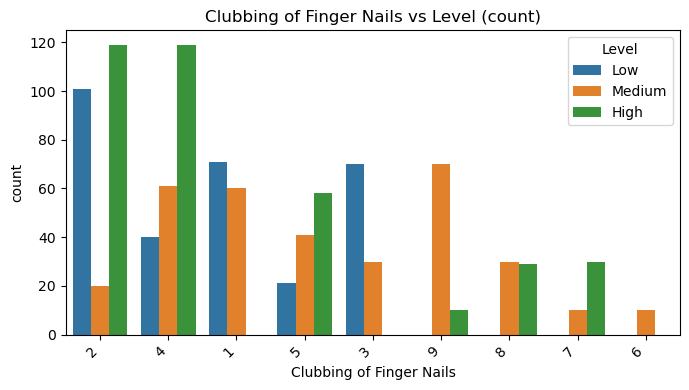

Conclusion: dominante por nivel -> High: 2, Low: 2, Medium: 9. Mayor brecha: Low (gap 0.33).

Variable: Frequent Cold


Level,High,Low,Medium
Frequent Cold,,,
1,0.079452,0.198020,0.150602
2,0.082192,0.435644,0.090361
3,0.106849,0.234323,0.361446
4,0.326027,0.066007,0.123494
5,0.000000,0.066007,0.000000
6,0.326027,0.000000,0.153614
7,0.079452,0.000000,0.120482


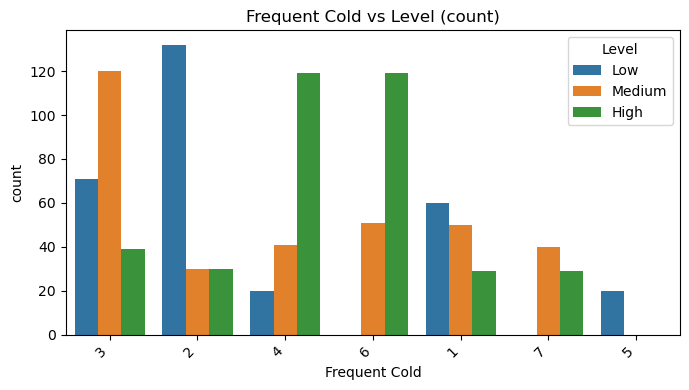

Conclusion: dominante por nivel -> High: 4, Low: 2, Medium: 3. Mayor brecha: Low (gap 0.44).

Variable: Dry Cough


Level,High,Low,Medium
Dry Cough,,,
1,0.106849,0.198020,0.060241
2,0.164384,0.231023,0.364458
3,0.082192,0.234323,0.000000
4,0.000000,0.201320,0.240964
5,0.136986,0.066007,0.183735
6,0.158904,0.069307,0.030120
7,0.350685,0.000000,0.120482


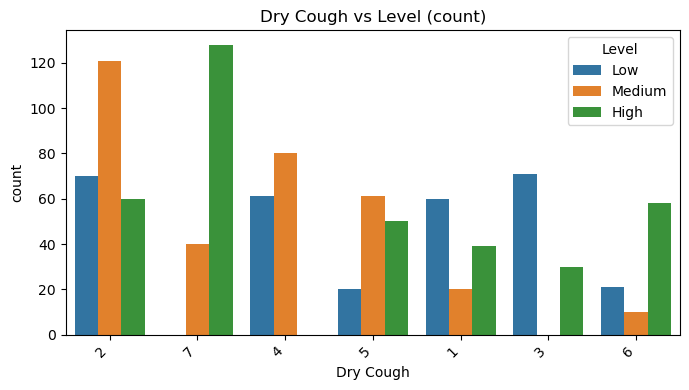

Conclusion: dominante por nivel -> High: 7, Low: 3, Medium: 2. Mayor brecha: Medium (gap 0.36).

Variable: Snoring


Level,High,Low,Medium
Snoring,,,
1,0.082192,0.330033,0.120482
2,0.298630,0.333333,0.271084
3,0.273973,0.201320,0.150602
4,0.106849,0.135314,0.153614
5,0.158904,0.000000,0.243976
6,0.052055,0.000000,0.060241
7,0.027397,0.000000,0.000000


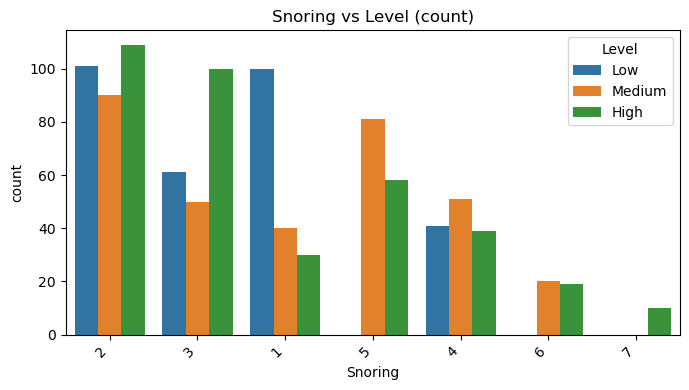

Conclusion: dominante por nivel -> High: 2, Low: 2, Medium: 2. Mayor brecha: Low (gap 0.33).


,var1,var2,corr
4,OccuPational Hazards,Genetic Risk,0.893049
1,Alcohol use,OccuPational Hazards,0.878786
2,Alcohol use,Genetic Risk,0.877210
5,OccuPational Hazards,chronic Lung Disease,0.858284
6,Genetic Risk,chronic Lung Disease,0.836231
3,Dust Allergy,OccuPational Hazards,0.835860
7,Genetic Risk,Chest Pain,0.831751
0,Alcohol use,Dust Allergy,0.818644
8,Obesity,Coughing of Blood,0.814805


Conclusion: existen pares altamente correlacionados. Esto puede causar multicolinealidad y redundancia en modelos lineales.


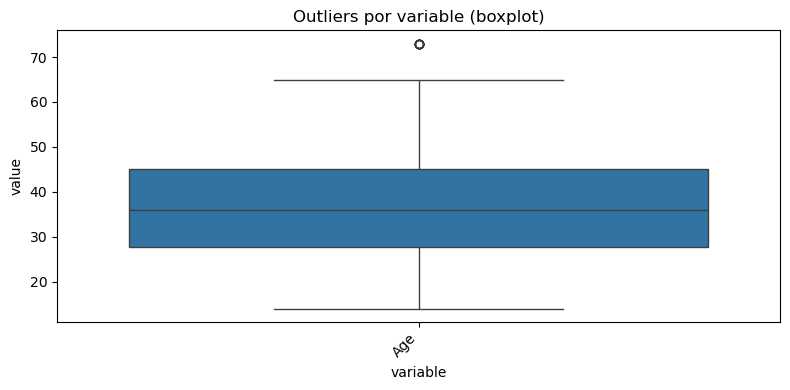

,variable,outlier_count
0,Age,10


Conclusion: se detectan outliers en algunas variables; podrian afectar modelos sensibles a escala.
Symptom columns: ['Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring']


,mean
Column,
Coughing of Blood,4.859
Chest Pain,4.438
Shortness of Breath,4.240
Clubbing of Finger Nails,3.923
Fatigue,3.856
Weight Loss,3.855
Dry Cough,3.853
Wheezing,3.777
Swallowing Difficulty,3.746


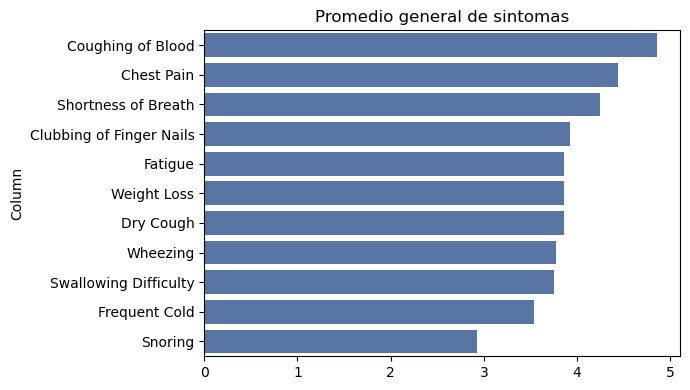

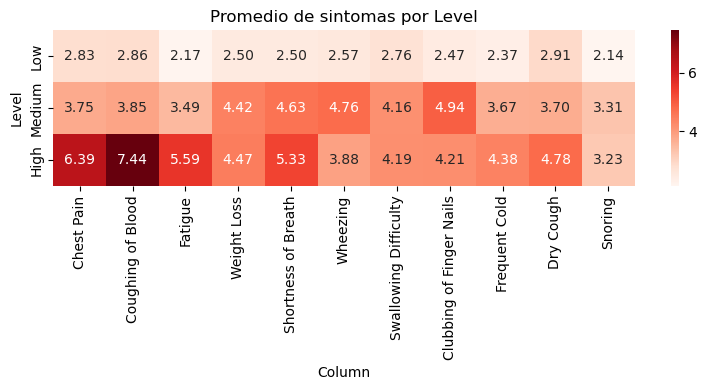

Conclusion: mayor aumento en nivel alto (High) vs bajo (Low):
Column
Coughing of Blood      4.576970
Chest Pain             3.556797
Fatigue                3.417424
Shortness of Breath    2.830417
Frequent Cold          2.014485
Insight: algunas variables de sintomas aumentan notablemente en niveles altos.


In [10]:
# EDA avanzado: categoricas/discretas vs Level, multicolinealidad, outliers, sintomas
target = "Level"
df_work = df.copy()

def infer_level_order(series):
    if pd.api.types.is_numeric_dtype(series):
        return sorted(series.dropna().unique())
    levels = [x for x in series.dropna().unique()]
    ranks = []
    for v in levels:
        s = str(v).lower()
        if "low" in s:
            ranks.append(0)
        elif "medium" in s:
            ranks.append(1)
        elif "high" in s:
            ranks.append(2)
        else:
            ranks.append(99)
    if any(r < 99 for r in ranks):
        return [x for _, x in sorted(zip(ranks, levels))]
    return sorted(levels)

def is_categorical_or_discrete(series, max_unique):
    if pd.api.types.is_bool_dtype(series) or pd.api.types.is_object_dtype(series) or pd.api.types.is_categorical_dtype(series):
        return True
    if pd.api.types.is_numeric_dtype(series):
        return series.nunique(dropna=True) <= max_unique
    return False

def summarize_categorical_vs_level(df_in, target_col):
    max_unique = max(5, min(12, int(0.05 * len(df_in))))
    level_order = infer_level_order(df_in[target_col])
    cat_cols = [c for c in df_in.columns if c != target_col and is_categorical_or_discrete(df_in[c], max_unique)]
    print(f"Categorical/discrete columns ({len(cat_cols)}): {cat_cols}")
    for col in cat_cols:
        print("\nVariable:", col)
        ct = pd.crosstab(df_in[col], df_in[target_col], normalize="columns")
        display(ct)
        plt.figure(figsize=(7, 4))
        order = df_in[col].value_counts().index
        sns.countplot(data=df_in, x=col, hue=target_col, order=order, hue_order=level_order)
        plt.title(f"{col} vs {target_col} (count)")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
        if ct.shape[0] > 0 and ct.shape[1] > 0:
            dominant = ct.apply(lambda s: s.idxmax())
            spread = (ct.max() - ct.min()).sort_values(ascending=False)
            gap_info = f"{spread.index[0]} (gap {spread.iloc[0]:.2f})" if not spread.empty else "n/a"
            dom_info = ", ".join([f"{k}: {v}" for k, v in dominant.items()])
            print(f"Conclusion: dominante por nivel -> {dom_info}. Mayor brecha: {gap_info}.")
        else:
            print("Conclusion: tabla vacia para esta variable.")

def high_corr_pairs(corr, threshold=0.8):
    cols = corr.columns
    pairs = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            val = corr.iloc[i, j]
            if abs(val) > threshold:
                pairs.append((cols[i], cols[j], val))
    if not pairs:
        return pd.DataFrame(columns=["var1", "var2", "corr"])
    df_pairs = pd.DataFrame(pairs, columns=["var1", "var2", "corr"])
    df_pairs["abs_corr"] = df_pairs["corr"].abs()
    return df_pairs.sort_values("abs_corr", ascending=False).drop(columns=["abs_corr"])

def iqr_outlier_counts(df_in, cols):
    records = []
    for col in cols:
        s = df_in[col].dropna()
        if s.empty:
            records.append((col, 0))
            continue
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = s[(s < lower) | (s > upper)]
        records.append((col, int(outliers.count())))
    return pd.DataFrame(records, columns=["variable", "outlier_count"]).sort_values("outlier_count", ascending=False)

def plot_boxplots_in_chunks(df_in, cols, chunk_size=6):
    for i in range(0, len(cols), chunk_size):
        subset = cols[i:i + chunk_size]
        if not subset:
            continue
        data = df_in[subset].melt(var_name="variable", value_name="value")
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=data, x="variable", y="value")
        plt.title("Outliers por variable (boxplot)")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

def normalize_col(name):
    return "".join([c for c in str(name).lower() if c.isalnum()])

def symptom_analysis(df_in, target_col):
    symptom_candidates = [
        "Chest Pain", "Coughing of Blood", "Fatigue", "Weight Loss",
        "Shortness of Breath", "Wheezing", "Swallowing Difficulty",
        "Clubbing of Finger Nails", "Frequent Cold", "Dry Cough", "Snoring"
    ]
    col_map = {normalize_col(c): c for c in df_in.columns}
    symptom_cols = [col_map[normalize_col(c)] for c in symptom_candidates if normalize_col(c) in col_map]
    if not symptom_cols:
        print("No symptom columns found from the candidate list.")
        return
    level_order = infer_level_order(df_in[target_col])
    print("Symptom columns:", symptom_cols)
    overall = df_in[symptom_cols].mean().sort_values(ascending=False)
    display(overall.to_frame("mean"))
    plt.figure(figsize=(7, 4))
    sns.barplot(x=overall.values, y=overall.index, color="#4C72B0")
    plt.title("Promedio general de sintomas")
    plt.tight_layout()
    plt.show()
    by_level = df_in.groupby(target_col)[symptom_cols].mean()
    if level_order:
        by_level = by_level.loc[level_order]
    plt.figure(figsize=(8, 4))
    sns.heatmap(by_level, annot=True, fmt=".2f", cmap="Reds")
    plt.title("Promedio de sintomas por Level")
    plt.tight_layout()
    plt.show()
    if len(by_level.index) >= 2:
        low = by_level.index[0]
        high = by_level.index[-1]
        delta = (by_level.loc[high] - by_level.loc[low]).sort_values(ascending=False)
        top = delta.head(5)
        print(f"Conclusion: mayor aumento en nivel alto ({high}) vs bajo ({low}):")
        print(top.to_string())
        if not top.empty and top.iloc[0] > 0.8:
            print("Insight: algunas variables de sintomas aumentan notablemente en niveles altos.")

# 1) Categoricas/discretas vs Level
summarize_categorical_vs_level(df_work, target)

# 2) Multicolinealidad
num_cols = [c for c in df_work.select_dtypes(include="number").columns if c != target]
if len(num_cols) > 1:
    corr = df_work[num_cols].corr()
    high_pairs = high_corr_pairs(corr, threshold=0.8)
    display(high_pairs)
    if len(num_cols) <= 20:
        plt.figure(figsize=(9, 6))
        sns.heatmap(corr, cmap="coolwarm", center=0)
        plt.title("Matriz de correlacion (numericas)")
        plt.tight_layout()
        plt.show()
    if high_pairs.empty:
        print("Conclusion: no hay pares con correlacion > 0.8.")
    else:
        print("Conclusion: existen pares altamente correlacionados. Esto puede causar multicolinealidad y redundancia en modelos lineales.")
        if high_pairs["corr"].abs().max() > 0.9:
            print("Insight: hay correlaciones muy altas (>0.9) que podrian sugerir variables redundantes.")
else:
    print("Conclusion: no hay suficientes variables numericas para analizar correlacion.")

# 3) Outliers (IQR)
max_unique = max(5, min(12, int(0.05 * len(df_work))))
num_cont_cols = [c for c in num_cols if df_work[c].nunique(dropna=True) > max_unique]
if num_cont_cols:
    plot_boxplots_in_chunks(df_work, num_cont_cols, chunk_size=6)
    outlier_df = iqr_outlier_counts(df_work, num_cont_cols)
    display(outlier_df)
    if outlier_df["outlier_count"].sum() == 0:
        print("Conclusion: no se detectan outliers con IQR.")
    else:
        print("Conclusion: se detectan outliers en algunas variables; podrian afectar modelos sensibles a escala.")
else:
    print("Conclusion: no hay variables numericas continuas para outliers.")

# 4) Analisis de sintomas
symptom_analysis(df_work, target)